In [22]:
# Import necessary libraries

# evaluate bagging ensemble for regression
from numpy import mean
from numpy import std
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor
import matplotlib.pyplot as plt
import pandas as pd 
import itertools
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [23]:
# Read the dataset
df = pd.read_csv("temperature.csv")

# Take a quick look at the data
df.head()

,x,y
0,0.758146,58.900258
1,3.517923,61.007477
2,7.697014,60.769837
3,13.707799,62.640141
4,10.654371,65.845652


In [24]:
# Assign "x" column as the predictor variable and "y" as the
x = df[['x']].values
y = df['y']

### Bagging Regressor

In [25]:
# Specify the number of bootstraps
num_bootstraps = 100

# Specify the maximum depth of the decision tree
max_depth = 2

# Define the Bagging Regressor Model
# Use Decision Tree as your base estimator with depth as mentioned in max_depth
# Initialise number of estimators using the num_bootstraps value
# Set bootstrap_features and max_samples as 0.8
model = BaggingRegressor(DecisionTreeRegressor(max_depth=max_depth),
                         n_estimators=num_bootstraps,max_samples=0.8,
                         bootstrap_features=True)

# Fit the model on the entire data
model.fit(x, y);

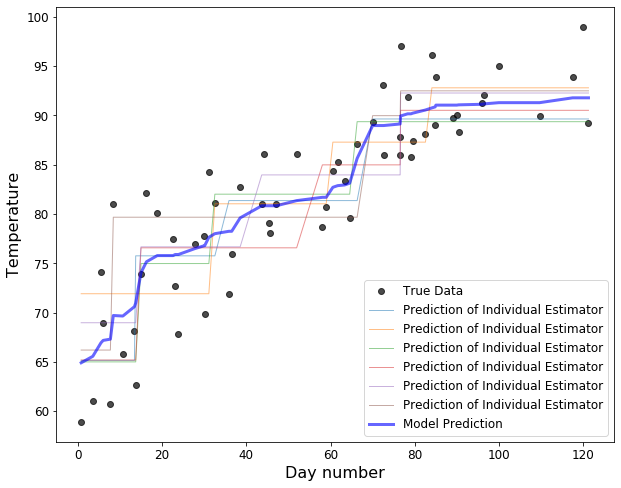

In [26]:
plt.figure(figsize=(10,8))

plt.plot(x,y,'o',color='black', alpha=0.7, markersize=6, label="True Data")
plt.xlim()
for i in model.estimators_[0:6]:
    y_pred1 = i.predict(x)
    x1,y_pred1 = zip(*sorted(zip(x, y_pred1)))
    plt.plot(x1,y_pred1,alpha=0.5,linewidth=1,label='Prediction of Individual Estimator')


y_pred = model.predict(x)
x1,y_pred = zip(*sorted(zip(x, y_pred)))
plt.plot(x1,y_pred,alpha=0.6,linewidth=3,color='blue', label='Model Prediction')
plt.xlabel("Day number", fontsize=16)
plt.ylabel("Temperature", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.show()

In [27]:
# Compute the MSE of the model prediction
print("The MSE of the model is",round(mean_squared_error(y,y_pred),3))

The MSE of the model is 19.963


In [28]:
# Compute the MSE of the prediction of individual estimator
print("The MSE of one estimator in the model is", round(mean_squared_error(y,y_pred1),3))

The MSE of one estimator in the model is 27.519
